# import library

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import entropy

# merge data

In [ ]:
data_path = '/home/agung/Documents/alcr/ABC2026 Sozolab Challenge-20260110T085845Z-1-001/ABC2026 Sozolab Challenge/Dataset/BLE Data'

file_name = '4 day'

rssi_list = ['1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16', '17','18','19','20', '21','22', '23','24','25']

mac_list = ['F7:7F:78:76:7E:F3',
            'C6:CD:5E:3D:2F:BB',
            'D6:F4:3A:79:74:63',
            'C9:17:55:E2:3E:0E',
            'CA:60:AB:EE:EC:7F',
            'D6:51:7F:AB:0E:29',
            'CC:54:33:F6:A7:90',
            'EB:20:56:87:04:5A',
            'EE:E7:46:DC:19:6F',
            'C8:5B:BF:37:07:A0',
            'D7:26:F6:A3:44:D2',
            'DD:83:B0:27:FD:36',
            'E5:CD:4A:36:87:06',
            'DC:22:B8:17:4E:B5',
            'EA:09:20:80:D6:44',
            'E6:99:D1:EC:C6:81',
            'F6:DA:97:C7:D5:28',
            'EA:66:A1:12:2C:F4',
            'C9:EA:57:8B:0F:80',
            'D6:7C:1D:2C:2A:0A',
            'DA:E1:70:5F:44:97',
            'DD:10:10:F6:4F:27',
            'E6:F3:93:A8:9E:22',
            'E6:60:05:1F:88:F9',
            'D4:33:FD:F4:C2:A8']

file_list = os.listdir(data_path)

csv_data = []
for csv_file in file_list:
  csv_data.append(pd.read_csv(os.path.join(data_path,csv_file),names=['user_id','timestamp','name', 'mac address', 'RSSI', 'power']))

df = csv_data[0]
for i in range(1,len(csv_data)):
  df = pd.concat([df,csv_data[i]])

print(df.shape)
df.head(5)

In [ ]:
# df.to_csv('df_concatenated.csv', index=False)

# load data

In [ ]:
df = pd.read_csv('../../dataset/df_concatenated.csv')
label = pd.read_csv('../../dataset/Dataset/5f_label_loc_train.csv')

# eda

In [ ]:
print(df.info())

print(label.info())

## rssi

In [ ]:
df.head(1)

In [ ]:
print(df['user_id'].value_counts())
print(df['name'].value_counts())

In [ ]:
print(df['mac address'].nunique())
print(df['power'].nunique())
print(df['RSSI'].nunique())

In [ ]:
plt.hist(df['power'])

In [ ]:
plt.hist(df['RSSI'])

## label

In [ ]:
label.head(1)

In [ ]:
print(label['activity'].value_counts())
print(label['user_id'].value_counts())
print(label['user'].value_counts())
print(label['room'].value_counts())
print(label['floor'].value_counts())

# preprocessing

## cleaning

In [ ]:
df = df.drop(columns=['name'])

label = label.drop(columns=['Unnamed: 0.1', 'Unnamed: 0', 'user', 'floor'])

In [ ]:
# rename agar jelas
label = label.rename(columns={
    'started_at': 'start_time',
    'finished_at': 'stop_time'
})

# parse waktu
label['start_time'] = pd.to_datetime(label['start_time'], errors='coerce')
label['stop_time']  = pd.to_datetime(label['stop_time'], errors='coerce')

# hitung durasi
label['duration'] = (label['stop_time'] - label['start_time']).dt.total_seconds()

# filter valid
label = label[
    label['start_time'].notna() &
    label['stop_time'].notna() &
    (label['duration'] > 0) &
    label['deleted_at'].isna()
]

# hapus null penting & duplikat
label = label.dropna(subset=['room'])
label = label.drop_duplicates()

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df[df['timestamp'].notna()]

In [ ]:
df['timestamp'] = df['timestamp'].dt.tz_convert('Asia/Tokyo')
label['start_time'] = label['start_time'].dt.tz_convert('Asia/Tokyo')
label['stop_time'] = label['stop_time'].dt.tz_convert('Asia/Tokyo')

In [ ]:
label = label.loc[label['activity'] == 'Location']
label = label.drop(columns=['deleted_at', 'updated_at', 'activity'])

In [ ]:
df = df.sort_values('timestamp').reset_index(drop=True)
label = label.sort_values('start_time').reset_index(drop=True)

In [ ]:
# ambil rentang label
start_label = label['start_time'].min()
end_label = label['stop_time'].max()

# potong RSSI ke rentang label
df = df[(df['timestamp'] >= start_label) & (df['timestamp'] <= end_label)].copy()

print(df['timestamp'].min(), df['timestamp'].max())

In [ ]:
print(start_label)
print(end_label)

In [ ]:
rooms = []
lbl = label.to_dict('records')
j = 0
n = len(lbl)

for ts in df['timestamp']:
    # geser interval label sampai stop_time >= ts
    while j < n and ts > lbl[j]['stop_time']:
        j += 1

    if j < n and lbl[j]['start_time'] <= ts <= lbl[j]['stop_time']:
        rooms.append(lbl[j]['room'])
    else:
        rooms.append(np.nan)

df['room'] = rooms

# buang RSSI tanpa label
df1 = df.dropna(subset=['room']).reset_index(drop=True)


In [ ]:
print(df1.shape)
print(df1['room'].value_counts())

In [ ]:
df1.info()

In [ ]:
df1.to_csv('../../dataset/df_cleaned.csv')

## feature engineering

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import entropy

In [2]:
df = pd.read_csv('../../dataset/df_cleaned.csv')

In [3]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df[df['timestamp'].notna()]
df = df.drop(columns=['Unnamed: 0'])

In [4]:
mac_list = ['F7:7F:78:76:7E:F3',
            'C6:CD:5E:3D:2F:BB',
            'D6:F4:3A:79:74:63',
            'C9:17:55:E2:3E:0E',
            'CA:60:AB:EE:EC:7F',
            'D6:51:7F:AB:0E:29',
            'CC:54:33:F6:A7:90',
            'EB:20:56:87:04:5A',
            'EE:E7:46:DC:19:6F',
            'C8:5B:BF:37:07:A0',
            'D7:26:F6:A3:44:D2',
            'DD:83:B0:27:FD:36',
            'E5:CD:4A:36:87:06',
            'DC:22:B8:17:4E:B5',
            'EA:09:20:80:D6:44',
            'E6:99:D1:EC:C6:81',
            'F6:DA:97:C7:D5:28',
            'EA:66:A1:12:2C:F4',
            'C9:EA:57:8B:0F:80',
            'D6:7C:1D:2C:2A:0A',
            'DA:E1:70:5F:44:97',
            'DD:10:10:F6:4F:27',
            'E6:F3:93:A8:9E:22',
            'E6:60:05:1F:88:F9',
            'D4:33:FD:F4:C2:A8']

df = df[df['mac address'].isin(mac_list)]
df = df.sort_values('timestamp').reset_index(drop=True)

In [5]:
WINDOW = '45s'
df['window_start'] = df['timestamp'].dt.floor(WINDOW)

room_per_window = (
    df.groupby('window_start')['room']
      .nunique()
      .value_counts()
)

room_per_window

room
1    729
2    175
3     35
4      4
5      1
Name: count, dtype: int64

In [6]:
valid_windows = (
    df.groupby('window_start')['room']
      .nunique()
      .reset_index()
)

valid_windows = valid_windows[valid_windows['room'] == 1]['window_start']

df = df[df['window_start'].isin(valid_windows)].reset_index(drop=True)

df.groupby('window_start')['room'].nunique().value_counts()

room
1    729
Name: count, dtype: int64

In [7]:
# RSSI matrix: window x beacon
rssi_matrix = (
    df
    .groupby(['window_start', 'mac address'])['RSSI']
    .mean()              
    .unstack('mac address')
    .sort_index()
)

In [8]:
agg_funcs = ['mean', 'std', 'var', 'min', 'max', 'median', 'sum', 'count']

feat = (
    df
    .groupby(['window_start', 'room', 'mac address'])['RSSI']
    .agg(agg_funcs)
    .unstack('mac address')
)

# flatten kolom: {mac}_{stat}
feat.columns = [f'{mac}_{stat}' for stat, mac in feat.columns]
feat = feat.reset_index()

In [9]:
feat['hour'] = feat['window_start'].dt.hour
feat['minute'] = feat['window_start'].dt.minute
feat['second'] = feat['window_start'].dt.second

In [10]:
feat = feat.fillna(0)

In [11]:
feat.columns.tolist()

['window_start',
 'room',
 'C6:CD:5E:3D:2F:BB_mean',
 'C8:5B:BF:37:07:A0_mean',
 'C9:17:55:E2:3E:0E_mean',
 'C9:EA:57:8B:0F:80_mean',
 'CA:60:AB:EE:EC:7F_mean',
 'CC:54:33:F6:A7:90_mean',
 'D4:33:FD:F4:C2:A8_mean',
 'D6:51:7F:AB:0E:29_mean',
 'D6:7C:1D:2C:2A:0A_mean',
 'D6:F4:3A:79:74:63_mean',
 'D7:26:F6:A3:44:D2_mean',
 'DA:E1:70:5F:44:97_mean',
 'DC:22:B8:17:4E:B5_mean',
 'DD:10:10:F6:4F:27_mean',
 'DD:83:B0:27:FD:36_mean',
 'E5:CD:4A:36:87:06_mean',
 'E6:60:05:1F:88:F9_mean',
 'E6:99:D1:EC:C6:81_mean',
 'E6:F3:93:A8:9E:22_mean',
 'EA:09:20:80:D6:44_mean',
 'EA:66:A1:12:2C:F4_mean',
 'EB:20:56:87:04:5A_mean',
 'EE:E7:46:DC:19:6F_mean',
 'F6:DA:97:C7:D5:28_mean',
 'F7:7F:78:76:7E:F3_mean',
 'C6:CD:5E:3D:2F:BB_std',
 'C8:5B:BF:37:07:A0_std',
 'C9:17:55:E2:3E:0E_std',
 'C9:EA:57:8B:0F:80_std',
 'CA:60:AB:EE:EC:7F_std',
 'CC:54:33:F6:A7:90_std',
 'D4:33:FD:F4:C2:A8_std',
 'D6:51:7F:AB:0E:29_std',
 'D6:7C:1D:2C:2A:0A_std',
 'D6:F4:3A:79:74:63_std',
 'D7:26:F6:A3:44:D2_std',
 'DA:E1:70:5F

# modelling

In [12]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [13]:
X = feat.drop(columns=['window_start', 'room'])
y = feat['room']

In [14]:
X.columns = (
    X.columns
    .str.replace(':', '_', regex=False)
    .str.replace('-', '_', regex=False)
    .str.replace(' ', '_', regex=False)
)

In [15]:
X.columns.tolist()

['C6_CD_5E_3D_2F_BB_mean',
 'C8_5B_BF_37_07_A0_mean',
 'C9_17_55_E2_3E_0E_mean',
 'C9_EA_57_8B_0F_80_mean',
 'CA_60_AB_EE_EC_7F_mean',
 'CC_54_33_F6_A7_90_mean',
 'D4_33_FD_F4_C2_A8_mean',
 'D6_51_7F_AB_0E_29_mean',
 'D6_7C_1D_2C_2A_0A_mean',
 'D6_F4_3A_79_74_63_mean',
 'D7_26_F6_A3_44_D2_mean',
 'DA_E1_70_5F_44_97_mean',
 'DC_22_B8_17_4E_B5_mean',
 'DD_10_10_F6_4F_27_mean',
 'DD_83_B0_27_FD_36_mean',
 'E5_CD_4A_36_87_06_mean',
 'E6_60_05_1F_88_F9_mean',
 'E6_99_D1_EC_C6_81_mean',
 'E6_F3_93_A8_9E_22_mean',
 'EA_09_20_80_D6_44_mean',
 'EA_66_A1_12_2C_F4_mean',
 'EB_20_56_87_04_5A_mean',
 'EE_E7_46_DC_19_6F_mean',
 'F6_DA_97_C7_D5_28_mean',
 'F7_7F_78_76_7E_F3_mean',
 'C6_CD_5E_3D_2F_BB_std',
 'C8_5B_BF_37_07_A0_std',
 'C9_17_55_E2_3E_0E_std',
 'C9_EA_57_8B_0F_80_std',
 'CA_60_AB_EE_EC_7F_std',
 'CC_54_33_F6_A7_90_std',
 'D4_33_FD_F4_C2_A8_std',
 'D6_51_7F_AB_0E_29_std',
 'D6_7C_1D_2C_2A_0A_std',
 'D6_F4_3A_79_74_63_std',
 'D7_26_F6_A3_44_D2_std',
 'DA_E1_70_5F_44_97_std',
 'DC_22_B8_17

In [16]:
min_samples = 2
valid_rooms = y.value_counts()[y.value_counts() >= min_samples].index

mask = y.isin(valid_rooms)
X = X[mask]
y = y[mask]

In [17]:
print(X.shape, y.shape)
X.iloc[:2, :5]
y.value_counts()

(728, 203) (728,)


room
nurse station    146
kitchen          127
Office Small      82
cafeteria         67
Cafeteria D       61
Office Large      39
hallway           31
523               31
201               17
513               16
213               13
520               12
512               11
208               11
210               10
522                9
Cafeteria B        8
cleaning           7
511                5
515                5
501                4
508                3
202                3
503                3
Bathroom           3
510                2
Clean Room         2
Name: count, dtype: int64

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_enc = le.fit_transform(y)

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.3,
    random_state=42,
    stratify=y_enc
)

# Graph Neural Network for Room Localization

In [20]:
# # Install required libraries
# import subprocess
# import sys

# packages = [
#     'torch',
#     'torch-geometric',
#     'networkx',
#     'scikit-learn'
# ]

# for package in packages:
#     try:
#         if package == 'torch-geometric':
#             subprocess.check_call([sys.executable, "-m", "pip", "install", "torch-geometric", "-q"])
#         else:
#             __import__(package.replace('-', '_'))
#     except:
#         print(f"Installing {package}...")
#         if package == 'torch-geometric':
#             subprocess.check_call([sys.executable, "-m", "pip", "install", "torch-geometric", "-q"])
#         else:
#             subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

# print("Libraries imported successfully")


In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GraphConv, global_mean_pool
from sklearn.metrics import classification_report, accuracy_score, f1_score
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import StandardScaler

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


PyTorch version: 2.7.1+cu126
CUDA available: True


In [ ]:
# Create graph dataset class
class RSSIGraphDataset:
    """Convert RSSI features to graph representation for GNN"""
    
    def __init__(self, X, y, mac_list, feature_agg_funcs=['mean', 'std', 'var', 'min', 'max', 'median']):
        """
        X: feature dataframe with columns like 'MAC_mean', 'MAC_std', etc.
        y: room labels (encoded) - can be numpy array or pandas Series
        mac_list: list of MAC addresses (25 beacons)
        """
        self.X = X.reset_index(drop=True)
        # Handle both numpy arrays and pandas Series
        if isinstance(y, np.ndarray):
            self.y = pd.Series(y)
        else:
            self.y = y.reset_index(drop=True)
        self.mac_list = mac_list
        self.feature_agg_funcs = feature_agg_funcs
        
    def _extract_beacon_features(self, row):
        """Extract features for each beacon from one row"""
        # Returns dict: {mac: [min_rssi, max_rssi, count]}
        beacon_features = {}
        
        for mac in self.mac_list:
            min_key = f'{mac.replace(":", "_")}_min'
            max_key = f'{mac.replace(":", "_")}_max'
            count_key = f'{mac.replace(":", "_")}_count'
            
            # Try to get features; if not present, use 0
            min_rssi = self.X.loc[row.name, min_key] if min_key in self.X.columns else 0
            max_rssi = self.X.loc[row.name, max_key] if max_key in self.X.columns else 0
            count = self.X.loc[row.name, count_key] if count_key in self.X.columns else 0
            
            # Handle NaN values
            min_rssi = -1 if pd.isna(min_rssi) else min_rssi
            max_rssi = 0 if pd.isna(max_rssi) else max_rssi
            count = 0 if pd.isna(count) else count
            
            beacon_features[mac] = [min_rssi, max_rssi, count]
        
        return beacon_features
    
    def _create_graph(self, beacon_features):
        """Create graph with nodes=beacons, edges=RSSI weighted connections"""
        # Node features: [min_rssi, max_rssi, count] per beacon
        node_features = np.array([beacon_features[mac] for mac in self.mac_list], dtype=np.float32)
        
        # Normalize node features
        scaler = StandardScaler()
        node_features = scaler.fit_transform(node_features)
        
        # Create edges: connect beacons with RSSI presence (fully connected weighted by strength)
        edges = []
        edge_weights = []
        
        for i, mac_i in enumerate(self.mac_list):
            for j, mac_j in enumerate(self.mac_list):
                if i < j:  # Avoid duplicates and self-loops
                    # Weight = product of detection counts (indicator of connection strength)
                    count_i = beacon_features[mac_i][2]
                    count_j = beacon_features[mac_j][2]
                    weight = (count_i * count_j) / (max(count_i, count_j) + 1e-6)
                    
                    if weight > 0:  # Only add edges with positive weight
                        edges.append([i, j])
                        edges.append([j, i])  # Bidirectional
                        edge_weights.append(weight)
                        edge_weights.append(weight)
        
        # If no edges, create minimal connectivity
        if len(edges) == 0:
            # Connect to 3 nearest beacons based on RSSI strength
            for i in range(len(self.mac_list)):
                strengths = [(j, beacon_features[self.mac_list[j]][2]) 
                            for j in range(len(self.mac_list)) if i != j]
                strengths.sort(key=lambda x: x[1], reverse=True)
                for j, _ in strengths[:3]:
                    if i < j:
                        edges.append([i, j])
                        edges.append([j, i])
                        edge_weights.append(1.0)
                        edge_weights.append(1.0)
        
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous() if len(edges) > 0 else torch.zeros((2, 0), dtype=torch.long)
        edge_attr = torch.tensor(edge_weights, dtype=torch.float32).unsqueeze(1) if len(edge_weights) > 0 else None
        
        return Data(
            x=torch.tensor(node_features, dtype=torch.float32),
            edge_index=edge_index,
            edge_attr=edge_attr
        )
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        row = self.X.iloc[idx]
        beacon_features = self._extract_beacon_features(row)
        graph = self._create_graph(beacon_features)
        graph.y = torch.tensor(self.y.iloc[idx], dtype=torch.long)
        return graph

# Create dataset
graph_dataset_train = RSSIGraphDataset(X_train, y_train, mac_list)
graph_dataset_test = RSSIGraphDataset(X_test, y_test, mac_list)

print(f"Training graphs: {len(graph_dataset_train)}")
print(f"Test graphs: {len(graph_dataset_test)}")
print(f"Number of beacons (nodes): {len(mac_list)}")


Training graphs: 509
Test graphs: 219
Number of beacons (nodes): 25


In [25]:
# Define GNN Model
class BeaconGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.3):
        super(BeaconGNN, self).__init__()
        self.conv1 = GraphConv(input_dim, hidden_dim)
        self.conv2 = GraphConv(hidden_dim, hidden_dim)
        self.conv3 = GraphConv(hidden_dim, hidden_dim)
        self.fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, edge_index, edge_attr, batch):
        # Graph convolution layers
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        
        # Global mean pooling
        x = global_mean_pool(x, batch)
        
        # Fully connected layers
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.fc2(x)
        return x

# Get number of classes
num_classes = len(np.unique(y_train))
print(f"Number of classes (rooms): {num_classes}")
print(f"Class labels: {le.classes_}")

# Create model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BeaconGNN(input_dim=3, hidden_dim=64, output_dim=num_classes, dropout=0.3)
model = model.to(device)

print(f"Model on device: {device}")
print(model)


Number of classes (rooms): 27
Class labels: ['201' '202' '208' '210' '213' '501' '503' '508' '510' '511' '512' '513'
 '515' '520' '522' '523' 'Bathroom' 'Cafeteria B' 'Cafeteria D'
 'Clean Room' 'Office Large' 'Office Small' 'cafeteria' 'cleaning'
 'hallway' 'kitchen' 'nurse station']
Model on device: cuda
BeaconGNN(
  (conv1): GraphConv(3, 64)
  (conv2): GraphConv(64, 64)
  (conv3): GraphConv(64, 64)
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=27, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [26]:
# Create data loaders
batch_size = 32
train_loader = DataLoader(graph_dataset_train, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(graph_dataset_test, batch_size=batch_size, shuffle=False)

# Training setup
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

# Training metrics storage
train_losses = []
train_accuracies = []
train_f1_scores = []
val_accuracies = []
val_f1_scores = []

def calculate_metrics(y_true, y_pred):
    """Calculate accuracy and F1 macro"""
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return acc, f1

# Training function
def train_epoch(epoch):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # Forward pass
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = criterion(out, batch.y)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        # Collect predictions
        preds = out.argmax(dim=1).detach().cpu().numpy()
        labels = batch.y.detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels)
    
    avg_loss = total_loss / len(train_loader)
    acc, f1 = calculate_metrics(all_labels, all_preds)
    
    train_losses.append(avg_loss)
    train_accuracies.append(acc)
    train_f1_scores.append(f1)
    
    return avg_loss, acc, f1

# Evaluation function
def evaluate():
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            preds = out.argmax(dim=1).detach().cpu().numpy()
            labels = batch.y.detach().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)
    
    acc, f1 = calculate_metrics(all_labels, all_preds)
    val_accuracies.append(acc)
    val_f1_scores.append(f1)
    
    return acc, f1

print("Starting training...")


Starting training...


/home/agung/Documents/dsai/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [27]:
# Train the model
num_epochs = 100

for epoch in range(num_epochs):
    train_loss, train_acc, train_f1 = train_epoch(epoch)
    val_acc, val_f1 = evaluate()
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{num_epochs} | "
              f"Loss: {train_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | "
              f"Train F1: {train_f1:.4f} | "
              f"Val Acc: {val_acc:.4f} | "
              f"Val F1: {val_f1:.4f}")

print("\nTraining completed!")

Epoch   1/100 | Loss: 5.1674 | Train Acc: 0.0530 | Train F1: 0.0181 | Val Acc: 0.0776 | Val F1: 0.0133
Epoch  10/100 | Loss: 2.5364 | Train Acc: 0.2652 | Train F1: 0.0520 | Val Acc: 0.3105 | Val F1: 0.0599
Epoch  20/100 | Loss: 2.4074 | Train Acc: 0.3163 | Train F1: 0.0672 | Val Acc: 0.3105 | Val F1: 0.0662
Epoch  30/100 | Loss: 2.3759 | Train Acc: 0.3202 | Train F1: 0.0664 | Val Acc: 0.3059 | Val F1: 0.0581
Epoch  40/100 | Loss: 2.3328 | Train Acc: 0.3301 | Train F1: 0.0744 | Val Acc: 0.3059 | Val F1: 0.0590
Epoch  50/100 | Loss: 2.2988 | Train Acc: 0.3517 | Train F1: 0.0814 | Val Acc: 0.2968 | Val F1: 0.0575
Epoch  60/100 | Loss: 2.3063 | Train Acc: 0.3301 | Train F1: 0.0687 | Val Acc: 0.2877 | Val F1: 0.0580
Epoch  70/100 | Loss: 2.2847 | Train Acc: 0.3438 | Train F1: 0.0792 | Val Acc: 0.3059 | Val F1: 0.0719
Epoch  80/100 | Loss: 2.2587 | Train Acc: 0.3222 | Train F1: 0.0798 | Val Acc: 0.3059 | Val F1: 0.0641
Epoch  90/100 | Loss: 2.2383 | Train Acc: 0.3438 | Train F1: 0.0925 | Val

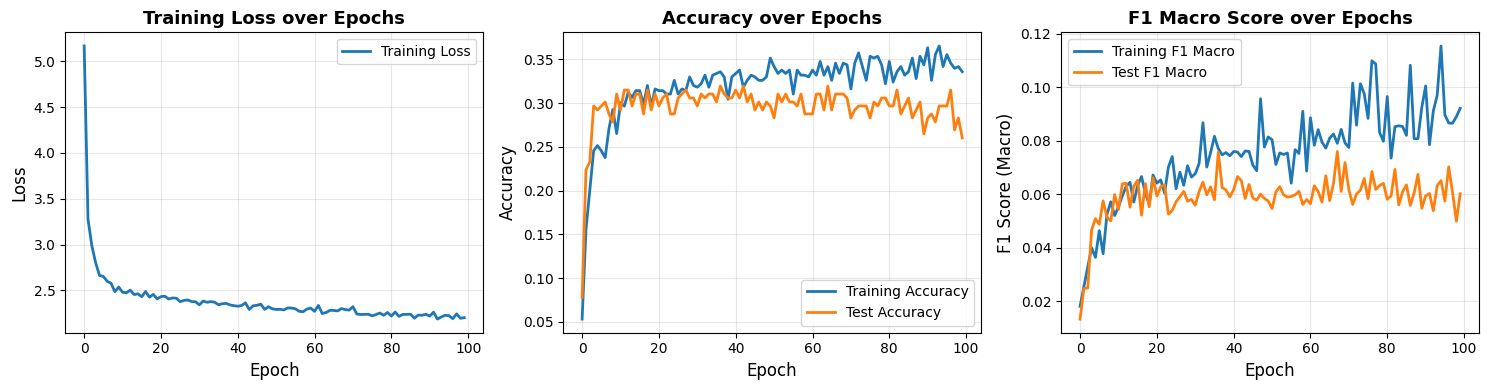


Best validation accuracy: 0.3196
Best validation F1 macro: 0.0760


In [28]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curve
axes[0].plot(train_losses, linewidth=2, label='Training Loss')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss over Epochs', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Accuracy curve
axes[1].plot(train_accuracies, linewidth=2, label='Training Accuracy')
axes[1].plot(val_accuracies, linewidth=2, label='Test Accuracy')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Accuracy over Epochs', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# F1 macro curve
axes[2].plot(train_f1_scores, linewidth=2, label='Training F1 Macro')
axes[2].plot(val_f1_scores, linewidth=2, label='Test F1 Macro')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('F1 Score (Macro)', fontsize=12)
axes[2].set_title('F1 Macro Score over Epochs', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\nBest validation accuracy: {max(val_accuracies):.4f}")
print(f"Best validation F1 macro: {max(val_f1_scores):.4f}")


In [29]:
# Test set evaluation with detailed classification report
model.eval()
test_preds = []
test_labels = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        preds = out.argmax(dim=1).detach().cpu().numpy()
        labels = batch.y.detach().cpu().numpy()
        test_preds.extend(preds)
        test_labels.extend(labels)

# Decode labels back to room names
test_preds_rooms = le.inverse_transform(test_preds)
test_labels_rooms = le.inverse_transform(test_labels)

# Print classification report
print("\n" + "="*80)
print("CLASSIFICATION REPORT (Test Data)")
print("="*80)
print(classification_report(test_labels_rooms, test_preds_rooms, digits=4))

# Print summary metrics
acc = accuracy_score(test_labels_rooms, test_preds_rooms)
f1_macro = f1_score(test_labels_rooms, test_preds_rooms, average='macro')
f1_weighted = f1_score(test_labels_rooms, test_preds_rooms, average='weighted')

print("\n" + "="*80)
print("SUMMARY METRICS")
print("="*80)
print(f"Overall Accuracy:        {acc:.4f}")
print(f"F1 Score (Macro):        {f1_macro:.4f}")
print(f"F1 Score (Weighted):     {f1_weighted:.4f}")
print("="*80)


CLASSIFICATION REPORT (Test Data)
               precision    recall  f1-score   support

          201     0.0000    0.0000    0.0000         5
          202     0.0000    0.0000    0.0000         1
          208     0.0000    0.0000    0.0000         3
          210     0.0000    0.0000    0.0000         3
          213     0.0000    0.0000    0.0000         4
          501     0.0000    0.0000    0.0000         1
          503     0.0000    0.0000    0.0000         1
          508     0.0000    0.0000    0.0000         1
          510     0.0000    0.0000    0.0000         1
          511     0.0000    0.0000    0.0000         2
          512     0.0000    0.0000    0.0000         3
          513     0.0000    0.0000    0.0000         5
          515     0.0000    0.0000    0.0000         1
          520     0.0000    0.0000    0.0000         4
          522     0.0000    0.0000    0.0000         3
          523     0.4444    0.4444    0.4444         9
     Bathroom     0.0000    0

/home/agung/Documents/dsai/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/agung/Documents/dsai/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/agung/Documents/dsai/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


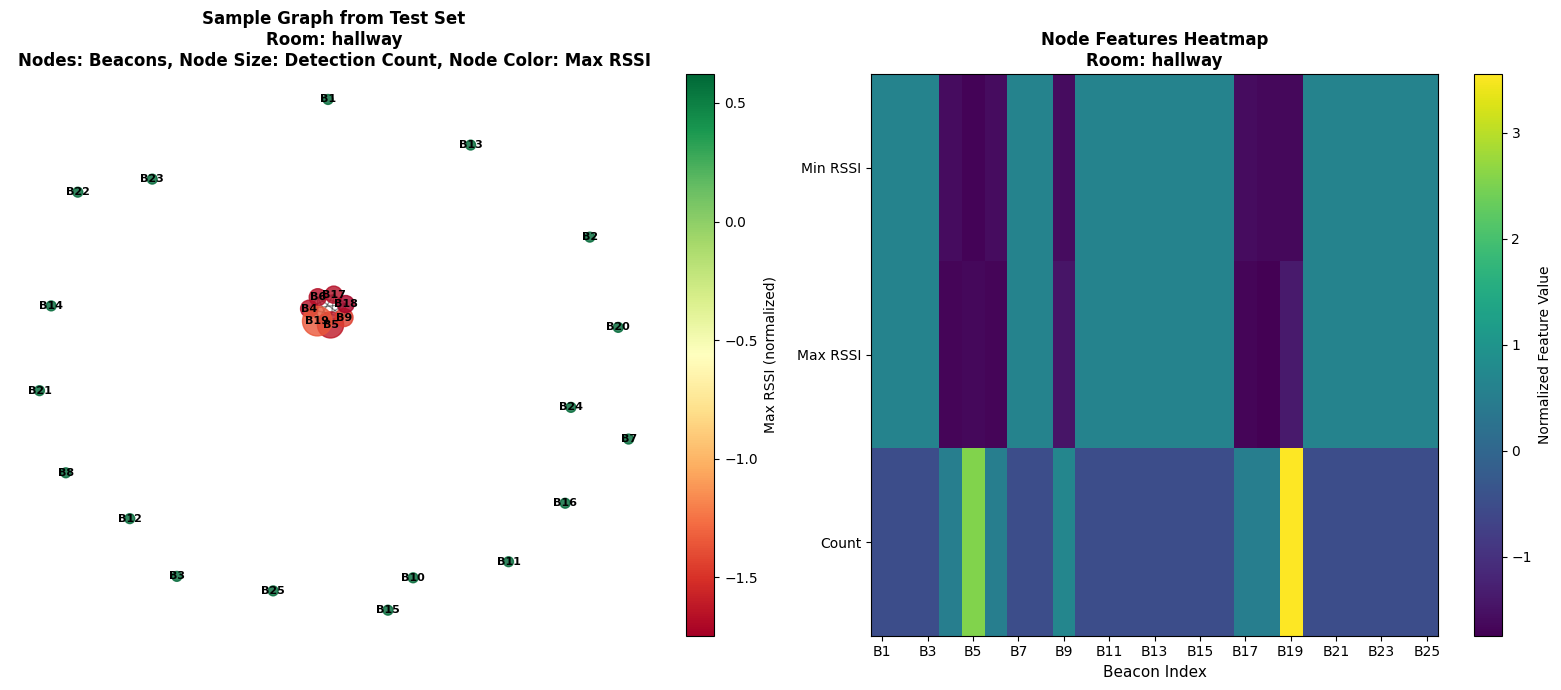


Sample Graph Visualization
  Room: hallway
  Number of nodes (beacons): 25
  Number of edges: 21
  Node features shape: (25, 3)
  Feature columns: ['Min RSSI', 'Max RSSI', 'Count']


In [30]:
# Visualize one sample graph from test set
sample_idx = 0
sample_graph = graph_dataset_test[sample_idx]
sample_room = le.inverse_transform([sample_graph.y.item()])[0]

# Extract node features and edge information
node_features = sample_graph.x.cpu().numpy()
edge_index = sample_graph.edge_index.cpu().numpy()
edge_attr = sample_graph.edge_attr.cpu().numpy() if sample_graph.edge_attr is not None else None

# Create NetworkX graph
G = nx.Graph()

# Add nodes with features
for i, mac in enumerate(mac_list):
    G.add_node(i, 
               label=f"B{i+1}",
               features=node_features[i])

# Add edges
if edge_index.shape[1] > 0:
    for edge_idx in range(edge_index.shape[1]):
        src = edge_index[0, edge_idx]
        dst = edge_index[1, edge_idx]
        weight = edge_attr[edge_idx, 0] if edge_attr is not None else 1.0
        if not G.has_edge(src, dst):
            G.add_edge(src, dst, weight=weight)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Network graph with node colors based on min RSSI
ax1 = axes[0]
pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42)

# Node colors based on max RSSI (feature 1)
node_colors = node_features[:, 1]  # max RSSI
node_sizes = (node_features[:, 2] + 1) * 100  # count

nodes = nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                               node_size=node_sizes, cmap='RdYlGn',
                               ax=ax1, alpha=0.8, vmin=node_colors.min(), 
                               vmax=node_colors.max())

# Draw edges with varying thickness based on weight
if len(G.edges()) > 0:
    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]
    max_weight = max(weights) if weights else 1
    edge_widths = [3 * (w / max_weight) for w in weights]
    
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.4, ax=ax1)

# Draw labels
labels = {i: f"B{i+1}" for i in range(len(mac_list))}
nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='bold', ax=ax1)

ax1.set_title(f"Sample Graph from Test Set\nRoom: {sample_room}\nNodes: Beacons, Node Size: Detection Count, Node Color: Max RSSI",
              fontsize=12, fontweight='bold')
ax1.axis('off')

# Colorbar for node colors
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(vmin=node_colors.min(), vmax=node_colors.max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax1, label='Max RSSI (normalized)', fraction=0.046, pad=0.04)

# Plot 2: Node features heatmap
ax2 = axes[1]
feature_names = ['Min RSSI', 'Max RSSI', 'Count']
heatmap_data = node_features

im = ax2.imshow(heatmap_data.T, cmap='viridis', aspect='auto')
ax2.set_yticks(range(len(feature_names)))
ax2.set_yticklabels(feature_names)
ax2.set_xlabel('Beacon Index', fontsize=11)
ax2.set_title(f"Node Features Heatmap\nRoom: {sample_room}",
              fontsize=12, fontweight='bold')
ax2.set_xticks(range(0, len(mac_list), 2))
ax2.set_xticklabels([f"B{i+1}" for i in range(0, len(mac_list), 2)])

cbar2 = plt.colorbar(im, ax=ax2, label='Normalized Feature Value')

plt.tight_layout()
plt.show()

print(f"\nSample Graph Visualization")
print(f"  Room: {sample_room}")
print(f"  Number of nodes (beacons): {G.number_of_nodes()}")
print(f"  Number of edges: {G.number_of_edges()}")
print(f"  Node features shape: {node_features.shape}")
print(f"  Feature columns: {feature_names}")


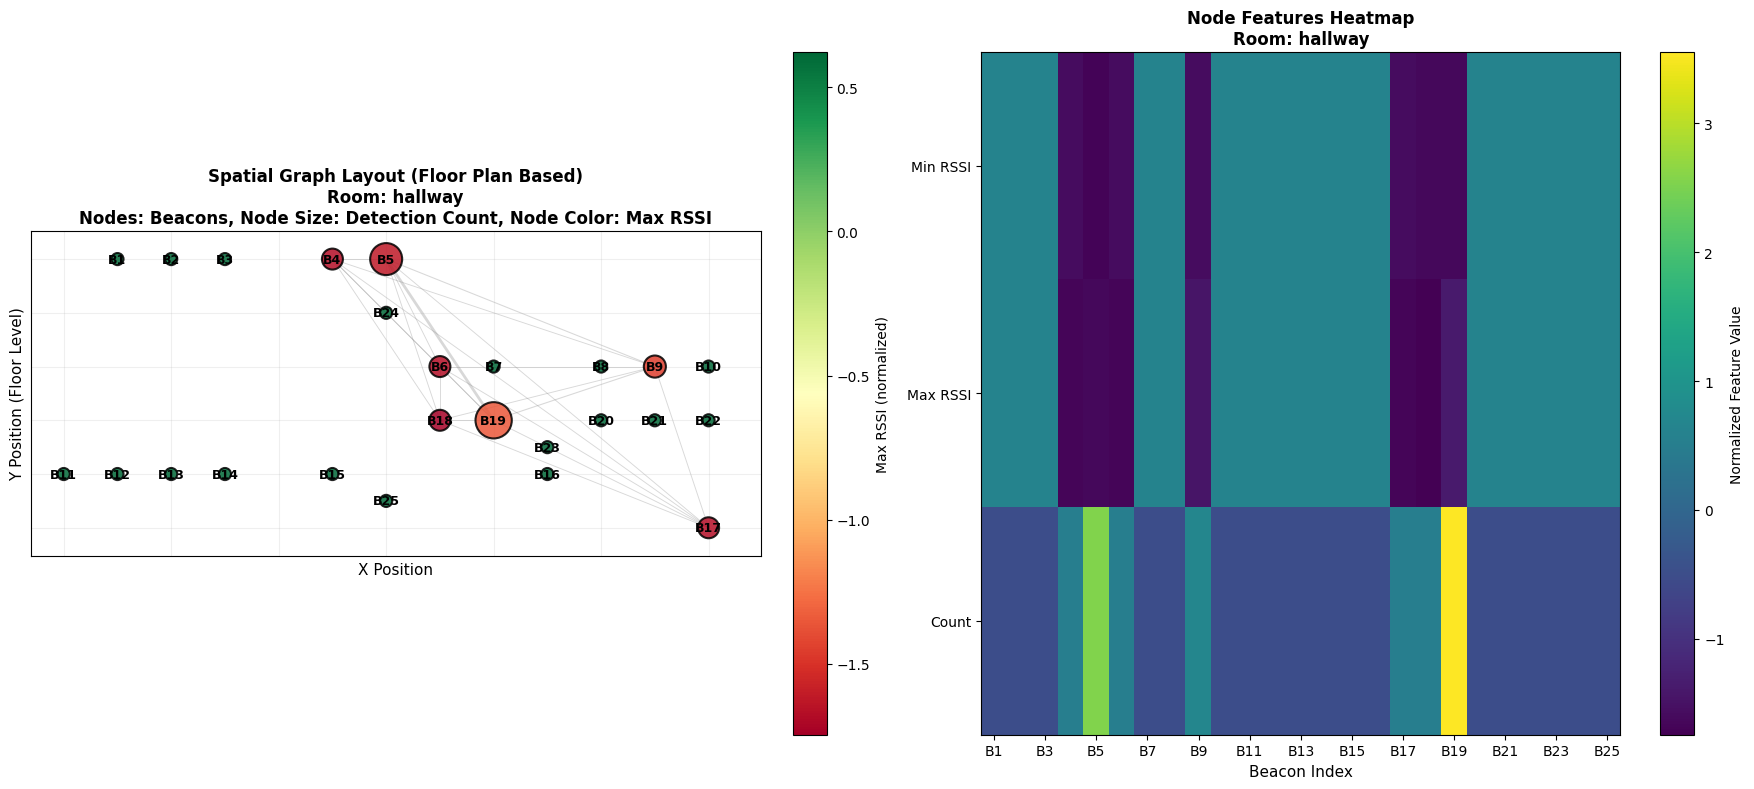


Spatial Graph Visualization (Based on Floor Plan)
  Room: hallway
  Number of nodes (beacons): 25
  Number of edges: 21
  Node features shape: (25, 3)
  Feature columns: ['Min RSSI', 'Max RSSI', 'Count']


In [31]:
# Spatial coordinates based on floor plan (estimated from the provided floor plan image)
# Beacon positions mapped to room coordinates
beacon_positions = {
    0: (1, 5),      # B1 - Room 1
    1: (2, 5),      # B2 - Room 2
    2: (3, 5),      # B3 - Room 3
    3: (5, 5),      # B4 - Room 5
    4: (6, 5),      # B5 - Room 6
    5: (7, 3),      # B6 - Room 7
    6: (8, 3),      # B7 - Room 8
    7: (10, 3),     # B8 - Room 10
    8: (11, 3),     # B9 - Room 11
    9: (12, 3),     # B10 - Room 12
    10: (0, 1),     # B11 - Room 13
    11: (1, 1),     # B12 - Room 15
    12: (2, 1),     # B13 - Room 16
    13: (3, 1),     # B14 - Room 17
    14: (5, 1),     # B15 - Kitchen/Toilet area
    15: (9, 1),     # B16 - Cafeteria
    16: (12, 0),    # B17 - Hallway
    17: (7, 2),     # B18 - Room 18
    18: (8, 2),     # B19 - Room 20
    19: (10, 2),    # B20 - Room 21
    20: (11, 2),    # B21 - Room 22
    21: (12, 2),    # B22 - Room 23
    22: (9, 1.5),   # B23 - Nurse Station
    23: (6, 4),     # B24 - Elevator/Cleaning
    24: (6, 0.5),   # B25 - additional beacon
}

# Recreate visualization with spatial layout
sample_idx = 0
sample_graph = graph_dataset_test[sample_idx]
sample_room = le.inverse_transform([sample_graph.y.item()])[0]

# Extract node features and edge information
node_features = sample_graph.x.cpu().numpy()
edge_index = sample_graph.edge_index.cpu().numpy()
edge_attr = sample_graph.edge_attr.cpu().numpy() if sample_graph.edge_attr is not None else None

# Create NetworkX graph
G_spatial = nx.Graph()

# Add nodes with spatial positions
for i, mac in enumerate(mac_list):
    G_spatial.add_node(i, 
                       label=f"B{i+1}",
                       features=node_features[i])

# Add edges
if edge_index.shape[1] > 0:
    for edge_idx in range(edge_index.shape[1]):
        src = edge_index[0, edge_idx]
        dst = edge_index[1, edge_idx]
        weight = edge_attr[edge_idx, 0] if edge_attr is not None else 1.0
        if not G_spatial.has_edge(src, dst):
            G_spatial.add_edge(src, dst, weight=weight)

# Visualization with spatial layout
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1: Spatial network graph based on floor plan
ax1 = axes[0]
pos = beacon_positions

# Node colors based on max RSSI
node_colors = node_features[:, 1]  # max RSSI
node_sizes = (node_features[:, 2] + 1) * 150  # count (scaled up for visibility)

nodes = nx.draw_networkx_nodes(G_spatial, pos, node_color=node_colors, 
                               node_size=node_sizes, cmap='RdYlGn',
                               ax=ax1, alpha=0.85, vmin=node_colors.min(), 
                               vmax=node_colors.max(), edgecolors='black', linewidths=1.5)

# Draw edges with varying thickness
if len(G_spatial.edges()) > 0:
    edges = G_spatial.edges()
    weights = [G_spatial[u][v]['weight'] for u, v in edges]
    max_weight = max(weights) if weights else 1
    edge_widths = [2 * (w / max_weight) for w in weights]
    
    nx.draw_networkx_edges(G_spatial, pos, width=edge_widths, alpha=0.3, ax=ax1, edge_color='gray')

# Draw labels
labels = {i: f"B{i+1}" for i in range(len(mac_list))}
nx.draw_networkx_labels(G_spatial, pos, labels, font_size=9, font_weight='bold', ax=ax1)

ax1.set_title(f"Spatial Graph Layout (Floor Plan Based)\nRoom: {sample_room}\nNodes: Beacons, Node Size: Detection Count, Node Color: Max RSSI",
              fontsize=12, fontweight='bold')
ax1.set_xlabel('X Position', fontsize=11)
ax1.set_ylabel('Y Position (Floor Level)', fontsize=11)
ax1.grid(True, alpha=0.2)
ax1.set_aspect('equal')

# Colorbar for node colors
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(vmin=node_colors.min(), vmax=node_colors.max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax1, label='Max RSSI (normalized)', fraction=0.046, pad=0.04)

# Plot 2: Node features heatmap
ax2 = axes[1]
feature_names = ['Min RSSI', 'Max RSSI', 'Count']
heatmap_data = node_features

im = ax2.imshow(heatmap_data.T, cmap='viridis', aspect='auto')
ax2.set_yticks(range(len(feature_names)))
ax2.set_yticklabels(feature_names)
ax2.set_xlabel('Beacon Index', fontsize=11)
ax2.set_title(f"Node Features Heatmap\nRoom: {sample_room}",
              fontsize=12, fontweight='bold')
ax2.set_xticks(range(0, len(mac_list), 2))
ax2.set_xticklabels([f"B{i+1}" for i in range(0, len(mac_list), 2)])

cbar2 = plt.colorbar(im, ax=ax2, label='Normalized Feature Value')

plt.tight_layout()
plt.show()

print(f"\nSpatial Graph Visualization (Based on Floor Plan)")
print(f"  Room: {sample_room}")
print(f"  Number of nodes (beacons): {G_spatial.number_of_nodes()}")
print(f"  Number of edges: {G_spatial.number_of_edges()}")
print(f"  Node features shape: {node_features.shape}")
print(f"  Feature columns: {feature_names}")


CURRENT IMPLEMENTATION: DYNAMIC ADJACENCY MATRIX

Edges are built per timestamp based on:
  - Beacon detection counts within a 45-second window
  - Connection weight = (count_i * count_j) / max(count_i, count_j)
  - Only edges with positive weight are kept
  - This means: edges change for EACH timestamp sample

Sample graph (idx=0):
  Number of edges: 42
  Edge list (first 10):
    B4 -- B5: weight=6.000
    B5 -- B4: weight=6.000
    B4 -- B6: weight=6.000
    B6 -- B4: weight=6.000
    B4 -- B9: weight=6.000
    B9 -- B4: weight=6.000
    B4 -- B17: weight=6.000
    B17 -- B4: weight=6.000
    B4 -- B18: weight=6.000
    B18 -- B4: weight=6.000

ALTERNATIVE: STATIC ADJACENCY MATRIX (FLOOR PLAN BASED)

Static adjacency based on spatial proximity (threshold=2.5 units):
  Beacons are connected if their floor-plan distance <= 2.5
  Connection weight = 1.0 / (distance + 0.1)  [inverse distance]

Total static edges: 126 (bidirectional)

Top 10 closest beacon pairs:
  B16 -- B23: distance=0

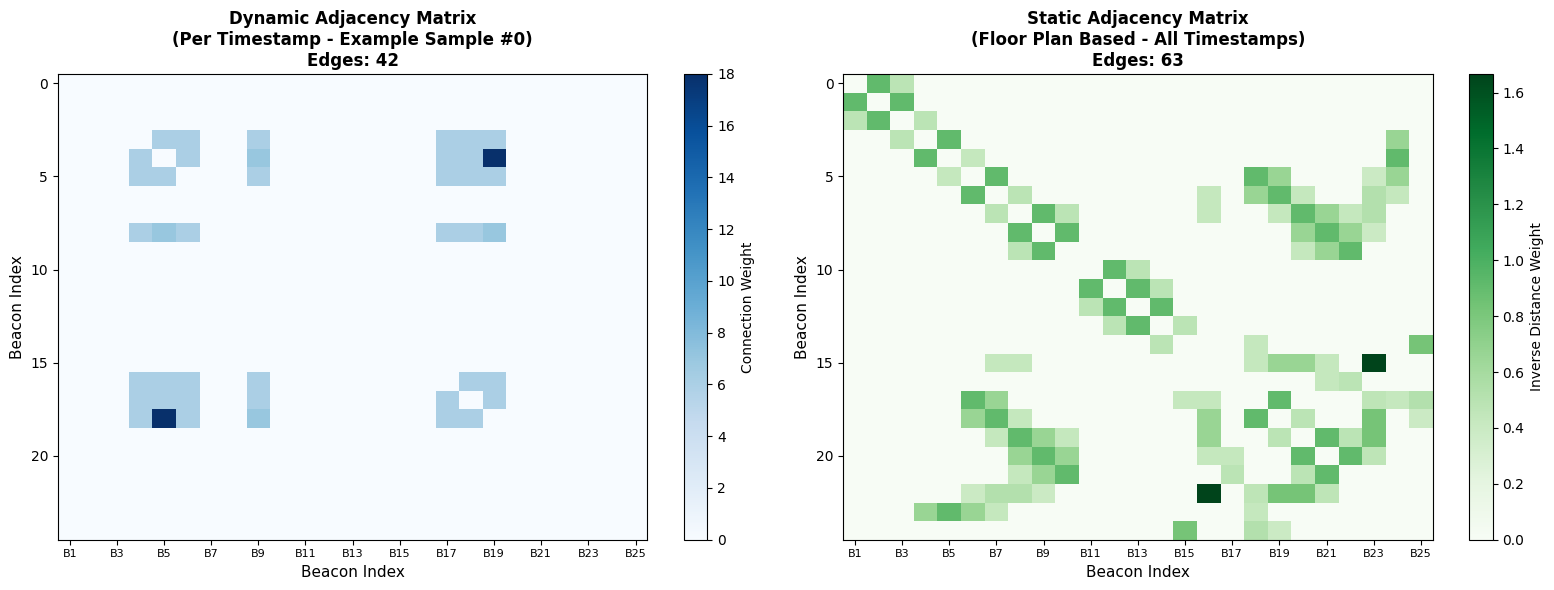


COMPARISON
Dynamic Adjacency (current):
  - Edges per sample:  VARIES (depends on detections)
  - Weight computation: RSSI-based co-occurrence
  - Advantage: Captures temporal patterns & signal strength
  - Disadvantage: Sparse & noisy per timestamp

Static Adjacency (floor plan based):
  - Edges per sample:  FIXED (63 always)
  - Weight computation: Spatial proximity (1/distance)
  - Advantage: Stable, leverages physical layout
  - Disadvantage: Ignores actual signal detections

Best practice: HYBRID approach could combine both
  - Use static edges from floor plan as backbone
  - Modulate weights dynamically by RSSI co-occurrence


In [33]:
## Adjacency Matrix Analysis: Dynamic vs Static (Floor Plan Based)

# Current implementation: DYNAMIC adjacency (per timestamp)
# Edges are created based on beacon detection co-occurrences in each timestamp window

print("="*80)
print("CURRENT IMPLEMENTATION: DYNAMIC ADJACENCY MATRIX")
print("="*80)
print(f"\nEdges are built per timestamp based on:")
print(f"  - Beacon detection counts within a 45-second window")
print(f"  - Connection weight = (count_i * count_j) / max(count_i, count_j)")
print(f"  - Only edges with positive weight are kept")
print(f"  - This means: edges change for EACH timestamp sample\n")

# Extract example graph to show adjacency structure
sample_idx = 0
sample_graph = graph_dataset_test[sample_idx]
edge_index = sample_graph.edge_index.cpu().numpy()
edge_attr = sample_graph.edge_attr.cpu().numpy() if sample_graph.edge_attr is not None else None

print(f"Sample graph (idx={sample_idx}):")
print(f"  Number of edges: {edge_index.shape[1]}")
if edge_index.shape[1] > 0:
    print(f"  Edge list (first 10):")
    for i in range(min(10, edge_index.shape[1])):
        src, dst = edge_index[0, i], edge_index[1, i]
        weight = edge_attr[i, 0] if edge_attr is not None else 1.0
        print(f"    B{src+1} -- B{dst+1}: weight={weight:.3f}")

# Now create STATIC adjacency based on floor plan spatial proximity
print("\n" + "="*80)
print("ALTERNATIVE: STATIC ADJACENCY MATRIX (FLOOR PLAN BASED)")
print("="*80)

# Calculate spatial distance between beacons
import numpy as np

def euclidean_distance(pos1, pos2):
    return np.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

# Create static adjacency based on spatial proximity threshold
static_adjacency = {}
distance_threshold = 2.5  # Connect beacons within 2.5 units

for i in range(len(mac_list)):
    static_adjacency[i] = []
    for j in range(i+1, len(mac_list)):
        pos_i = beacon_positions[i]
        pos_j = beacon_positions[j]
        dist = euclidean_distance(pos_i, pos_j)
        
        if dist <= distance_threshold:
            static_adjacency[i].append((j, dist))

print(f"\nStatic adjacency based on spatial proximity (threshold={distance_threshold} units):")
print(f"  Beacons are connected if their floor-plan distance <= {distance_threshold}")
print(f"  Connection weight = 1.0 / (distance + 0.1)  [inverse distance]\n")

# Build static adjacency matrix
static_edges = []
static_weights = []

for i in range(len(mac_list)):
    for j, dist in static_adjacency.get(i, []):
        weight = 1.0 / (dist + 0.1)  # Inverse distance weighting
        static_edges.append([i, j])
        static_edges.append([j, i])
        static_weights.append(weight)
        static_weights.append(weight)

print(f"Total static edges: {len(static_edges)} (bidirectional)")
print(f"\nTop 10 closest beacon pairs:")

all_pairs = []
for i in range(len(mac_list)):
    for j in range(i+1, len(mac_list)):
        pos_i = beacon_positions[i]
        pos_j = beacon_positions[j]
        dist = euclidean_distance(pos_i, pos_j)
        all_pairs.append((i, j, dist))

all_pairs.sort(key=lambda x: x[2])
for i, j, dist in all_pairs[:10]:
    print(f"  B{i+1} -- B{j+1}: distance={dist:.2f}")

# Visualize both adjacency matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Dynamic adjacency matrix (from current sample)
dynamic_adj_matrix = np.zeros((len(mac_list), len(mac_list)))
if edge_index.shape[1] > 0:
    for edge_idx in range(edge_index.shape[1]):
        src = edge_index[0, edge_idx]
        dst = edge_index[1, edge_idx]
        weight = edge_attr[edge_idx, 0] if edge_attr is not None else 1.0
        dynamic_adj_matrix[src, dst] = weight

# Static adjacency matrix
static_adj_matrix = np.zeros((len(mac_list), len(mac_list)))
for src, dst, weight in zip(static_edges[::2], [static_edges[i+1] for i in range(0, len(static_edges), 2)], static_weights[::2]):
    static_adj_matrix[src, dst] = weight

# Plot dynamic adjacency
ax1 = axes[0]
im1 = ax1.imshow(dynamic_adj_matrix, cmap='Blues', aspect='auto')
ax1.set_xlabel('Beacon Index', fontsize=11)
ax1.set_ylabel('Beacon Index', fontsize=11)
ax1.set_title(f'Dynamic Adjacency Matrix\n(Per Timestamp - Example Sample #{sample_idx})\nEdges: {edge_index.shape[1]}', 
              fontsize=12, fontweight='bold')
ax1.set_xticks(range(0, len(mac_list), 2))
ax1.set_xticklabels([f"B{i+1}" for i in range(0, len(mac_list), 2)], fontsize=8)
plt.colorbar(im1, ax=ax1, label='Connection Weight')

# Plot static adjacency
ax2 = axes[1]
im2 = ax2.imshow(static_adj_matrix, cmap='Greens', aspect='auto')
ax2.set_xlabel('Beacon Index', fontsize=11)
ax2.set_ylabel('Beacon Index', fontsize=11)
ax2.set_title(f'Static Adjacency Matrix\n(Floor Plan Based - All Timestamps)\nEdges: {len(static_edges)//2}',
              fontsize=12, fontweight='bold')
ax2.set_xticks(range(0, len(mac_list), 2))
ax2.set_xticklabels([f"B{i+1}" for i in range(0, len(mac_list), 2)], fontsize=8)
plt.colorbar(im2, ax=ax2, label='Inverse Distance Weight')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("COMPARISON")
print("="*80)
print(f"Dynamic Adjacency (current):")
print(f"  - Edges per sample:  VARIES (depends on detections)")
print(f"  - Weight computation: RSSI-based co-occurrence")
print(f"  - Advantage: Captures temporal patterns & signal strength")
print(f"  - Disadvantage: Sparse & noisy per timestamp\n")

print(f"Static Adjacency (floor plan based):")
print(f"  - Edges per sample:  FIXED ({len(static_edges)//2} always)")
print(f"  - Weight computation: Spatial proximity (1/distance)")
print(f"  - Advantage: Stable, leverages physical layout")
print(f"  - Disadvantage: Ignores actual signal detections\n")

print("Best practice: HYBRID approach could combine both")
print("  - Use static edges from floor plan as backbone")
print("  - Modulate weights dynamically by RSSI co-occurrence")
print("="*80)


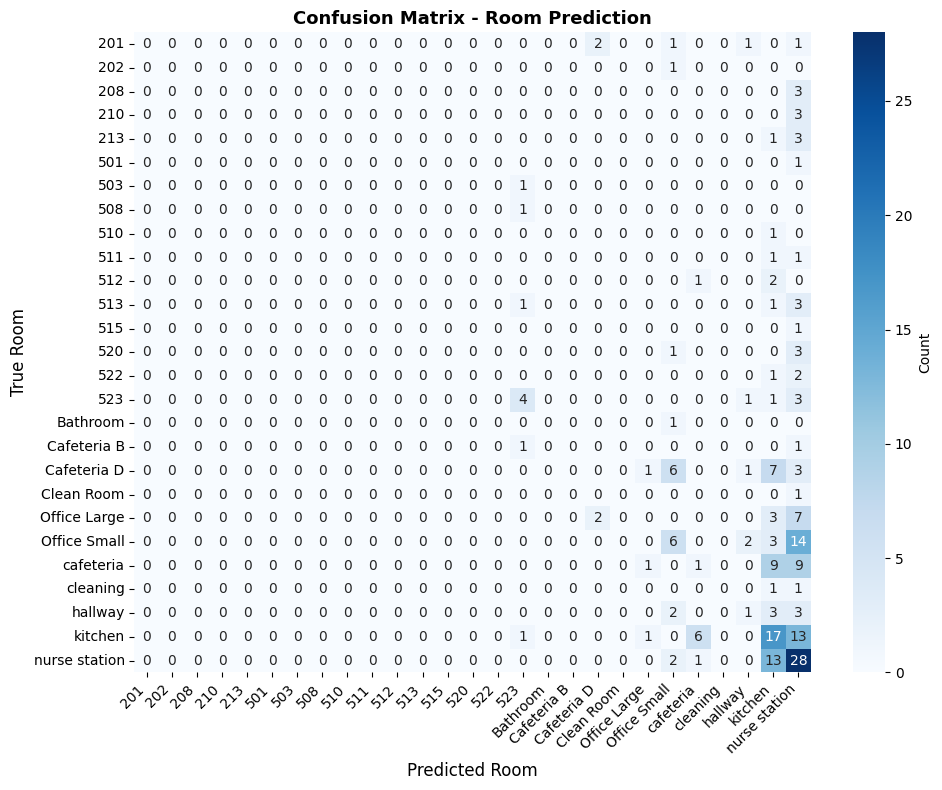

In [32]:
# Confusion Matrix Visualization
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(test_labels_rooms, test_preds_rooms)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Room', fontsize=12)
plt.ylabel('True Room', fontsize=12)
plt.title('Confusion Matrix - Room Prediction', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
